# PHÂN TÍCH MỨC ĐỘ SỬ DỤNG AI CỦA LẬP TRÌNH VIÊN

## I. GIỚI THIỆU & XÁC ĐỊNH VẤN ĐỀ 

### 1. Tổng quan đề tài: Phân tích mức độ sử dụng AI của lập trình viên 

### 2. Mục tiêu nghiên cứu: Sử dụng K-Means để khám phá tri thức và rút ra insight về các nhóm đối tượng 

### 3. Câu hỏi nghiên cứu: 
(Ví dụ: Có bao nhiêu nhóm Dev dựa trên mức độ sử dụng AI? Đặc điểm từng nhóm là gì?)


## II.THIẾT LẬP DỮ LIỆU 


### 1. Import thư viện: Khai báo các thư viện Python (Pandas, Sklearn, Seaborn...). 

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns


### 2. Tải dữ liệu: Cung cấp link nguồn public và uy tín 

Đoạn này mô tả sơ về dữ liệu 
mô tả 
gắn link 

In [4]:

df = pd.read_csv("survey_results_public.csv")


C:\Users\phamt\AppData\Local\Temp\ipykernel_26024\1270675122.py:1: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("survey_results_public.csv")


### 3.Mô tả Dataset: Thống kê số dòng, cột và ý nghĩa các thuộc tính quan trọng 

In [3]:




#  Thống kê số dòng và số cột [cite: 16]
print("--- TỔNG QUAN KÍCH THƯỚC DỮ LIỆU ---")
print(f"Số lượng dòng (records): {df.shape[0]}")
print(f"Số lượng cột (attributes): {df.shape[1]}")
print("-" * 40)

#  Xem thông tin kiểu dữ liệu và giá trị thiếu (Dùng cho bước EDA 1) [cite: 16, 22]
print("\n--- THÔNG TIN CÁC THUỘC TÍNH ---")
print(df.info())

#  Thống kê mô tả cơ bản (Mean, Median, Min, Max...) 
print("\n--- THỐNG KÊ MÔ TẢ CHO CÁC BIẾN SỐ ---")
display(df.describe())

#  Kiểm tra một vài dòng dữ liệu mẫu [cite: 72]
print("\n--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---")
display(df.head())

--- TỔNG QUAN KÍCH THƯỚC DỮ LIỆU ---
Số lượng dòng (records): 49191
Số lượng cột (attributes): 172
----------------------------------------

--- THÔNG TIN CÁC THUỘC TÍNH ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB
None

--- THỐNG KÊ MÔ TẢ CHO CÁC BIẾN SỐ ---


,ResponseId,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,ConvertedCompYearly,JobSat
count,49191.000000,42893.000000,43042.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,...,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,2.394700e+04,26670.000000
mean,24596.000000,13.367403,16.570861,7.867352,4.104211,4.110271,5.678193,4.119388,5.225990,6.477387,...,5.718355,4.561767,4.790861,5.199657,5.676314,4.984653,7.099505,10.079284,1.017615e+05,7.201950
std,14200.362883,10.800117,11.787610,2.397432,2.275821,2.329536,2.398084,2.437945,2.801045,2.331468,...,2.628016,3.070548,2.643177,2.563562,2.310659,2.490095,2.469394,1.940928,4.617569e+05,1.997245
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0.000000
25%,12298.500000,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,...,3.000000,1.000000,3.000000,3.000000,4.000000,3.000000,6.000000,10.000000,3.817100e+04,6.000000
50%,24596.000000,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,...,6.000000,4.000000,5.000000,5.000000,6.000000,5.000000,8.000000,10.000000,7.532000e+04,8.000000
75%,36893.500000,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,...,8.000000,7.000000,7.000000,7.000000,7.000000,7.000000,9.000000,10.000000,1.205960e+05,8.000000
max,49191.000000,100.000000,100.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,5.000000e+07,10.000000



--- 5 DÒNG DỮ LIỆU ĐẦU TIÊN ---


,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


## III. EDA GIAI ĐOẠN 1: TRƯỚC TIỀN XỬ LÝ  

Mục tiêu: Nhận diện thực trạng và các vấn đề của dữ liệu thô.

### 1. Phân phối thô (Raw Distribution): Sử dụng Histogram/Countplot để xem tần suất sử dụng AI ban đầu 

C:\Users\phamt\AppData\Local\Temp\ipykernel_26024\3555365301.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='AISelect', palette='viridis', order = df['AISelect'].value_counts().index)


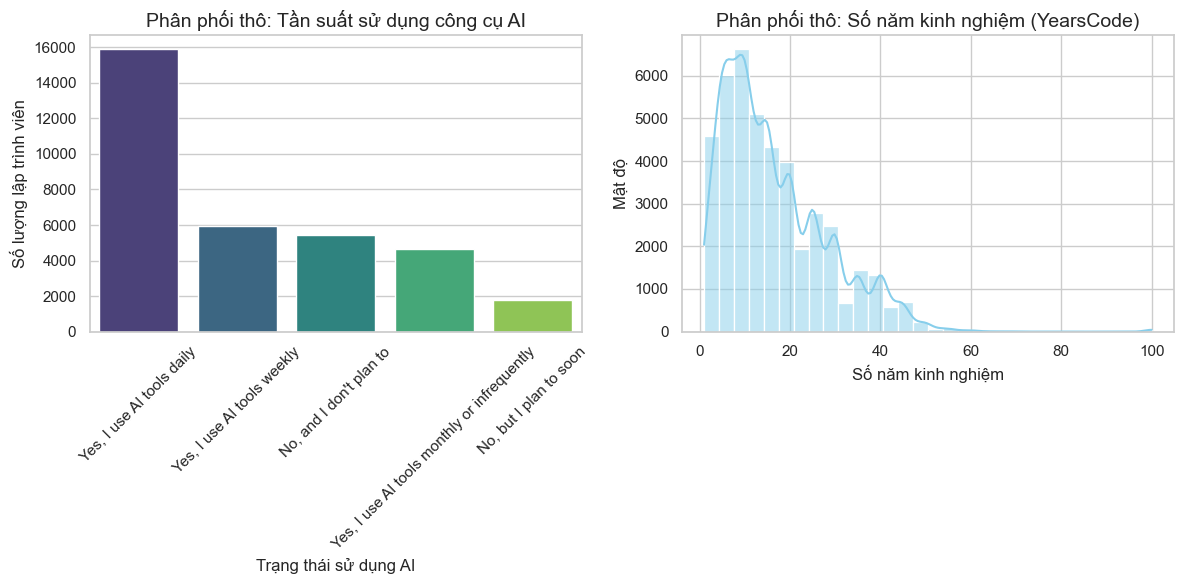

--- CHI TIẾT TẦN SUẤT SỬ DỤNG AI ---
AISelect
Yes, I use AI tools daily                      47.102610
Yes, I use AI tools weekly                     17.669039
No, and I don't plan to                        16.174377
Yes, I use AI tools monthly or infrequently    13.724792
No, but I plan to soon                          5.329181
Name: proportion, dtype: float64


In [9]:


# Giả sử các cột liên quan đến AI của bạn là 'AISelect' (Có dùng AI không) 
# và 'AISentiment' (Thái độ với AI). Bạn hãy thay tên cột đúng với dataset của mình
# Thiết lập phong cách cho biểu đồ
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Vẽ Countplot cho tần suất sử dụng AI (Dữ liệu định tính)
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='AISelect', palette='viridis', order = df['AISelect'].value_counts().index)
plt.title('Phân phối thô: Tần suất sử dụng công cụ AI', fontsize=14)
plt.xticks(rotation=45)
plt.xlabel('Trạng thái sử dụng AI')
plt.ylabel('Số lượng lập trình viên')

# 2. Vẽ Histogram cho một biến số liên quan (ví dụ: Điểm tin tưởng AI hoặc số năm kinh nghiệm)
# Ở đây tôi ví dụ với cột 'YearsCode' để xem phân phối kinh nghiệm của mẫu
plt.subplot(1, 2, 2)
sns.histplot(df['YearsCode'].dropna(), bins=30, kde=True, color='skyblue')
plt.title('Phân phối thô: Số năm kinh nghiệm (YearsCode)', fontsize=14)
plt.xlabel('Số năm kinh nghiệm')
plt.ylabel('Mật độ')

plt.tight_layout()
plt.show()

# Xuất ra bảng tần suất cụ thể để đưa vào báo cáo
print("--- CHI TIẾT TẦN SUẤT SỬ DỤNG AI ---")
print(df['AISelect'].value_counts(normalize=True) * 100) # Xem tỉ lệ %

### 2. Kiểm tra dữ liệu thiếu (Missing Values): Vẽ biểu đồ (như missingno hoặc Heatmap) để xác định các vùng trống 

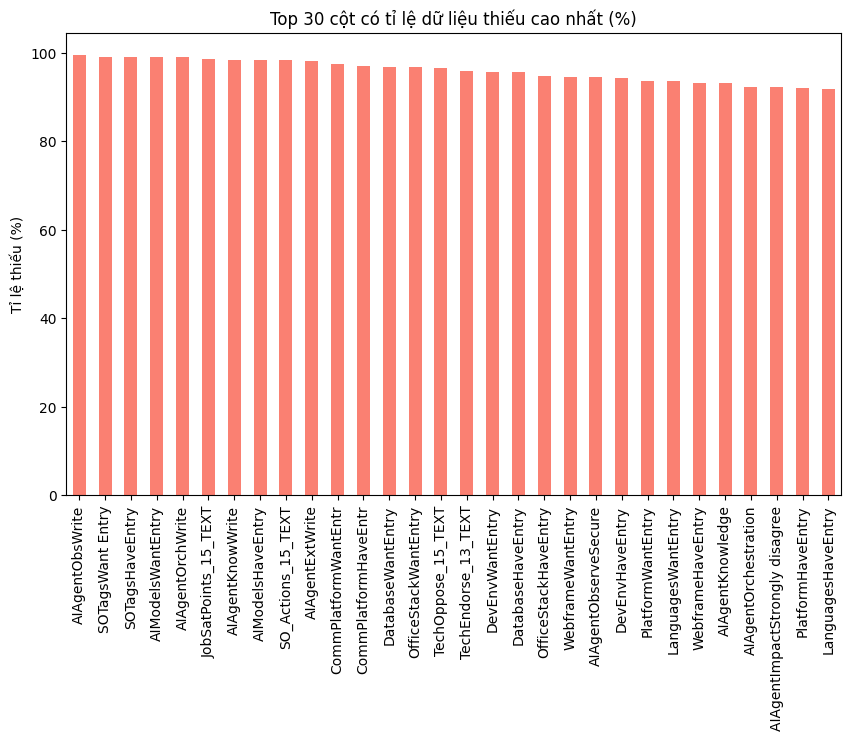

Các cột tiềm năng liên quan đến AI (43 cột):
['LearnCodeAI', 'AILearnHow', 'AIThreat', 'AIModelsChoice', 'AIModelsHaveWorkedWith', 'AIModelsWantToWorkWith', 'AIModelsAdmired', 'AIModelsHaveEntry', 'AIModelsWantEntry', 'AISelect', 'AISent', 'AIAcc', 'AIComplex', 'AIToolCurrently partially AI', "AIToolDon't plan to use AI for this task", 'AIToolPlan to partially use AI', 'AIToolPlan to mostly use AI', 'AIToolCurrently mostly AI', 'AIFrustration', 'AIExplain', 'AIAgents', 'AIAgentChange', 'AIAgent_Uses', 'AIAgentImpactSomewhat agree', 'AIAgentImpactNeutral', 'AIAgentImpactSomewhat disagree', 'AIAgentImpactStrongly agree', 'AIAgentImpactStrongly disagree', 'AIAgentChallengesNeutral', 'AIAgentChallengesSomewhat disagree', 'AIAgentChallengesStrongly agree', 'AIAgentChallengesSomewhat agree', 'AIAgentChallengesStrongly disagree', 'AIAgentKnowledge', 'AIAgentKnowWrite', 'AIAgentOrchestration', 'AIAgentOrchWrite', 'AIAgentObserveSecure', 'AIAgentObsWrite', 'AIAgentExternal', 'AIAgentExtWrite', 

In [5]:
# 1. Kiểm tra tỉ lệ giá trị thiếu của toàn bộ 172 cột
missing_data = df.isnull().mean() * 100
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

# 2. Vẽ biểu đồ các cột thiếu dữ liệu nhiều nhất
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
missing_data[:30].plot(kind='bar', color='salmon')
plt.title("Top 30 cột có tỉ lệ dữ liệu thiếu cao nhất (%)")
plt.ylabel("Tỉ lệ thiếu (%)")
plt.show()

# 3. Lọc nhanh các cột có chứa từ khóa 'AI' để tập trung EDA
ai_related_cols = [col for col in df.columns if 'AI' in col]
print(f"Các cột tiềm năng liên quan đến AI ({len(ai_related_cols)} cột):")
print(ai_related_cols)

In [6]:
# 1. Tính toán tỷ lệ giá trị thiếu cho mỗi cột
missing_ratio = df.isnull().mean() * 100

# 2. Lọc ra các cột có tỷ lệ thiếu > 50%
cols_over_50_missing = missing_ratio[missing_ratio > 50].sort_values(ascending=False)

# 3. Hiển thị thống kê
print(f"--- THỐNG KÊ CỘT THIẾU TRÊN 50% DỮ LIỆU ---")
print(f"Số lượng cột bị ảnh hưởng: {len(cols_over_50_missing)}")
if len(cols_over_50_missing) > 0:
    print("\nChi tiết danh sách và tỷ lệ thiếu (%):")
    print(cols_over_50_missing)
else:
    print("\nKhông có cột nào thiếu trên 50% dữ liệu.")

# 4. Gợi ý: Kiểm tra xem có cột AI quan trọng nào nằm trong danh sách này không
ai_related_cols = [col for col in df.columns if 'AI' in col]
overlap = set(cols_over_50_missing.index) & set(ai_related_cols)

if overlap:
    print("\n!!! CẢNH BÁO: Có các cột liên quan đến AI bị thiếu trên 50%:")
    print(list(overlap))

--- THỐNG KÊ CỘT THIẾU TRÊN 50% DỮ LIỆU ---
Số lượng cột bị ảnh hưởng: 71

Chi tiết danh sách và tỷ lệ thiếu (%):
AIAgentObsWrite               99.463316
SOTagsWant Entry              99.125856
SOTagsHaveEntry               99.068935
AIModelsWantEntry             99.034376
AIAgentOrchWrite              99.028278
                                ...    
CommPlatformWantToWorkWith    52.529934
LanguageAdmired               52.288020
ConvertedCompYearly           51.318331
PlatformHaveWorkedWith        50.686101
SO_Actions_16                 50.519404
Length: 71, dtype: float64

!!! CẢNH BÁO: Có các cột liên quan đến AI bị thiếu trên 50%:
['AIAgentChallengesStrongly disagree', 'AIAgentChallengesNeutral', 'AIModelsWantEntry', 'AIAgent_Uses', 'AIAgentKnowWrite', 'AIToolPlan to mostly use AI', 'AIModelsWantToWorkWith', 'AIModelsAdmired', 'AIToolCurrently mostly AI', 'AIAgentExternal', 'AIAgentImpactSomewhat disagree', 'AIAgentExtWrite', 'AIModelsHaveEntry', 'AIAgentImpactNeutral', 'AIAgentImp

In [7]:
# 5. Xác định danh sách các tên cột cần loại bỏ (từ kết quả bước 2)
cols_to_drop = cols_over_50_missing.index.tolist()

# 6. Thực hiện loại bỏ các cột này khỏi DataFrame
# Chúng ta tạo một DataFrame mới (df_reduced) để giữ lại dữ liệu gốc nếu cần đối chiếu
df_reduced = df.drop(columns=cols_to_drop)

# 7. Thông báo kết quả thực hiện
print(f"--- KẾT QUẢ LOẠI BỎ CỘT THIẾU > 50% ---")
print(f"Số lượng cột đã loại bỏ: {len(cols_to_drop)}")
print(f"Số lượng cột còn lại trong dataset: {df_reduced.shape[1]}")

# 8. Kiểm tra nhanh xem còn giá trị thiếu trên 50% không
remaining_missing = df_reduced.isnull().mean() * 100
if not any(remaining_missing > 50):
    print("Xác nhận: Không còn cột nào có tỷ lệ thiếu trên 50%.")

--- KẾT QUẢ LOẠI BỎ CỘT THIẾU > 50% ---
Số lượng cột đã loại bỏ: 71
Số lượng cột còn lại trong dataset: 101
Xác nhận: Không còn cột nào có tỷ lệ thiếu trên 50%.


### 3. Nhận diện giá trị ngoại lệ (Outliers): Sử dụng Boxplot để tìm các điểm dữ liệu bất thường có thể gây sai lệch cho K-Means 

C:\Users\phamt\AppData\Local\Temp\ipykernel_26024\4255761847.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_reduced, y=col, ax=axes[i], palette='Set2')
C:\Users\phamt\AppData\Local\Temp\ipykernel_26024\4255761847.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_reduced, y=col, ax=axes[i], palette='Set2')
C:\Users\phamt\AppData\Local\Temp\ipykernel_26024\4255761847.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_reduced, y=col, ax=axes[i], palette='Set2')
C:\Users\phamt\AppData\Local\Temp\ipykernel_26024

--- ĐÃ KIỂM TRA NGOẠI LỆ CHO 6 CỘT ---
Biểu đồ đã được lưu thành file 'outliers_boxplot.png'.


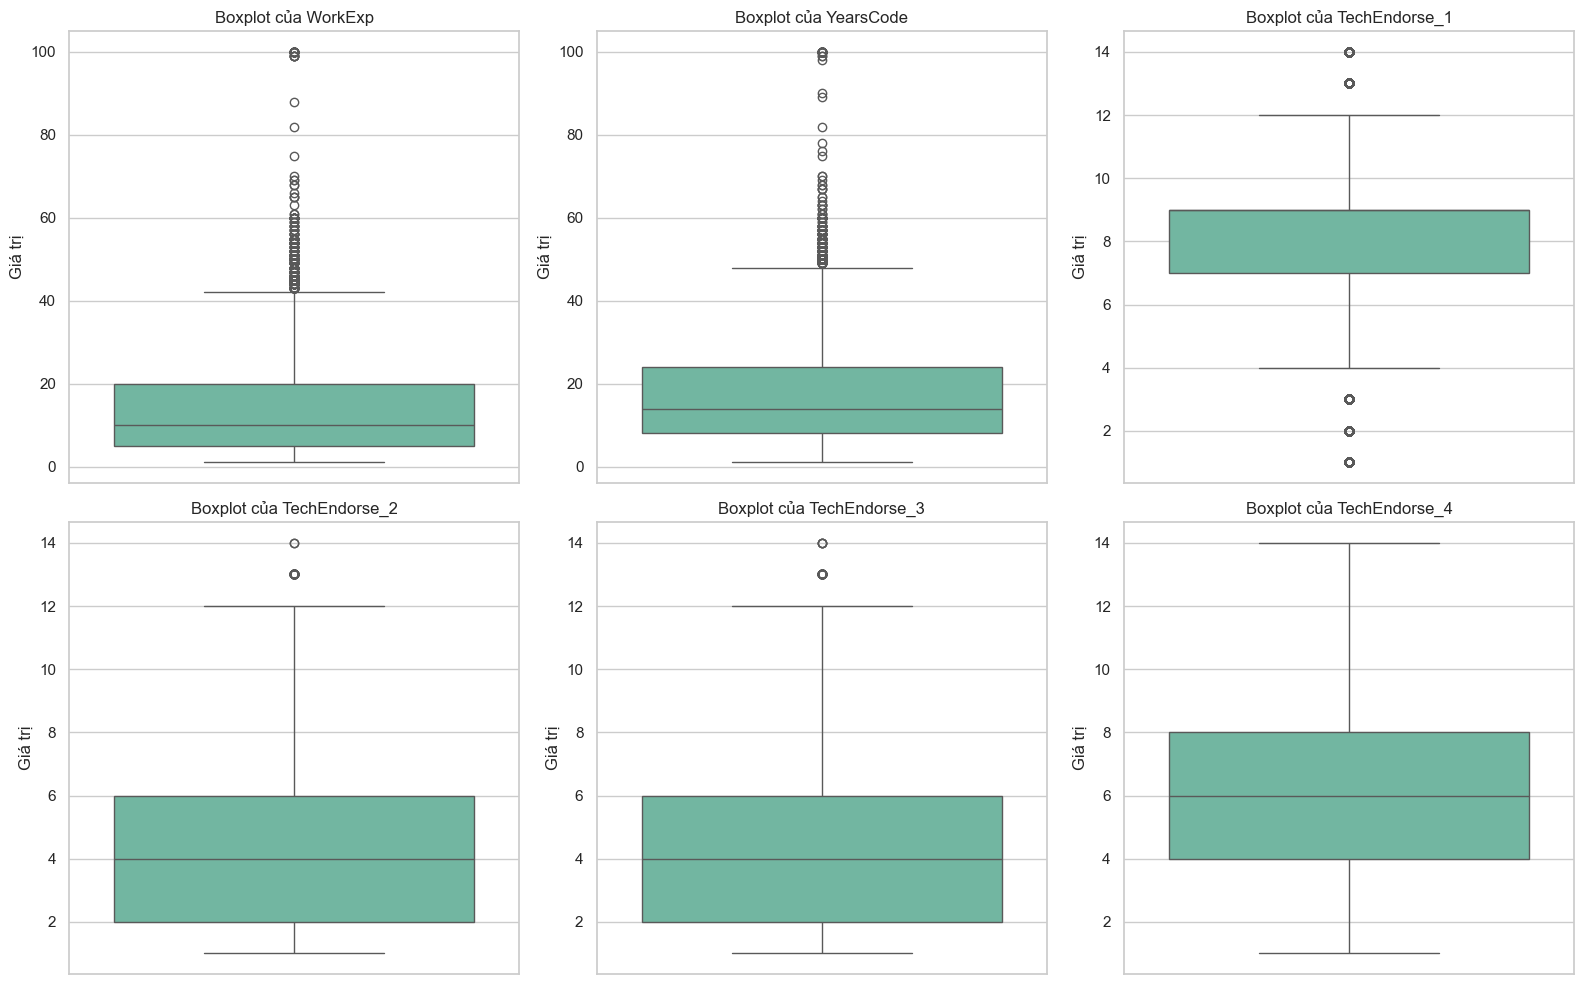

In [12]:
# 1. Lấy danh sách các cột kiểu số (Numerical) để vẽ boxplot
# Ở giai đoạn này, chúng ta tập trung vào các cột định lượng
numerical_cols = df_reduced.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Loại bỏ ResponseId nếu nó còn sót lại vì không có ý nghĩa phân tích ngoại lệ
if 'ResponseId' in numerical_cols:
    numerical_cols.remove('ResponseId')

# 2. Lựa chọn các cột quan trọng nhất để hiển thị (tránh vẽ quá nhiều gây rối)
# Ví dụ: 6 cột đầu tiên hoặc các cột bạn đã xác định là quan trọng
cols_to_plot = numerical_cols[:6] 

# 3. Vẽ Boxplot cho từng cột
# Lưu ý: Theo yêu cầu không sử dụng .figure(), ta sẽ dùng subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    sns.boxplot(data=df_reduced, y=col, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Boxplot của {col}', fontsize=12)
    axes[i].set_ylabel('Giá trị')

# Điều chỉnh khoảng cách và lưu ảnh (theo quy định không dùng .show())
plt.tight_layout()
plt.savefig('outliers_boxplot.png')

print(f"--- ĐÃ KIỂM TRA NGOẠI LỆ CHO {len(cols_to_plot)} CỘT ---")
print("Biểu đồ đã được lưu thành file 'outliers_boxplot.png'.")

## IV. TIỀN XỬ LÝ DỮ LIỆU (DATA PRE-PROCESSING)
 

### 1. Lọc thô (Initial Selection): Loại bỏ cột định danh (ID, Name) để tối ưu pipeline. 

In [13]:
# 1. Danh sách các cột định danh hoặc không có giá trị phân tích (Cần điều chỉnh theo dataset thực tế)
# Thông thường bao gồm ID, Tên, Email, hoặc các cột chứa URL
unnecessary_cols = ['ResponseId'] # 'ResponseId' thường là cột định danh trong Stack Overflow Survey

# 2. Kiểm tra xem các cột này có tồn tại trong DataFrame hiện tại (df_reduced) không
cols_to_drop_final = [col for col in unnecessary_cols if col in df_reduced.columns]

# 3. Tiến hành loại bỏ để tối ưu pipeline
df_final_selection = df_reduced.drop(columns=cols_to_drop_final)

# 4. Thông báo kết quả
print(f"--- KẾT QUẢ LỌC THÔ (INITIAL SELECTION) ---")
print(f"Danh sách cột đã loại bỏ: {cols_to_drop_final}")
print(f"Kích thước dữ liệu sau khi lọc thô: {df_final_selection.shape}")
print("-" * 40)

--- KẾT QUẢ LỌC THÔ (INITIAL SELECTION) ---
Danh sách cột đã loại bỏ: ['ResponseId']
Kích thước dữ liệu sau khi lọc thô: (49191, 100)
----------------------------------------


### 2. Xử lý dữ liệu thiếu: Áp dụng quy tắc xóa dòng thiếu >50% và gán giá trị (Imputation) cho phần còn lại

In [14]:
# --- BƯỚC 4.2: XỬ LÝ DỮ LIỆU THIẾU ---

# 1. Xóa các dòng (hàng) có trên 50% giá trị thiếu 
# Tính ngưỡng (ví dụ: nếu có 100 cột, dòng phải có ít nhất 50 giá trị non-NaN)
threshold = df_final_selection.shape[1] * 0.5 
df_clean_rows = df_final_selection.dropna(thresh=int(threshold), axis=0)

print(f"--- KẾT QUẢ XỬ LÝ HÀNG ---")
print(f"Số lượng dòng ban đầu: {df_final_selection.shape[0]}")
print(f"Số lượng dòng sau khi xóa (thiếu > 50%): {df_clean_rows.shape[0]}")
print(f"Đã loại bỏ {df_final_selection.shape[0] - df_clean_rows.shape[0]} dòng.")

# 2. Gán giá trị (Imputation) cho các cột còn lại [cite: 18, 20]
# Vì dữ liệu của bạn có cả Chữ (Object) và Số (Float/Int), ta cần xử lý riêng từng loại
df_imputed = df_clean_rows.copy()

# Lấy danh sách cột theo kiểu dữ liệu
num_cols = df_imputed.select_dtypes(include=['float64', 'int64']).columns
cat_cols = df_imputed.select_dtypes(include=['object']).columns

# Gán giá trị trung vị (Median) cho các cột số để tránh ảnh hưởng bởi Outliers [cite: 22]
for col in num_cols:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].median())

# Gán giá trị xuất hiện nhiều nhất (Mode) cho các cột phân loại (Chữ)
for col in cat_cols:
    df_imputed[col] = df_imputed[col].fillna(df_imputed[col].mode()[0])

print("\n--- KẾT QUẢ GÁN GIÁ TRỊ (IMPUTATION) ---")
print(f"Tổng số giá trị thiếu còn lại: {df_imputed.isnull().sum().sum()}")

--- KẾT QUẢ XỬ LÝ HÀNG ---
Số lượng dòng ban đầu: 49191
Số lượng dòng sau khi xóa (thiếu > 50%): 33836
Đã loại bỏ 15355 dòng.

--- KẾT QUẢ GÁN GIÁ TRỊ (IMPUTATION) ---
Tổng số giá trị thiếu còn lại: 0


### 3. Bước lọc các cột có giá trị với đề tài 

 Liệt kê tất cả các tên cột trong DataFrame hiện tại
 Hiển thị theo dạng danh sách có đánh số để dễ theo dõi

In [ ]:

print("--- DANH SÁCH TẤT CẢ CÁC CỘT CÓ TRONG DF ---")
column_list = df_imputed.columns.tolist()


for i, col in enumerate(column_list, 1):
    print(f"{i}. {col}")

print("-" * 40)
print(f"Tổng cộng có: {len(column_list)} cột.")

--- DANH SÁCH TẤT CẢ CÁC CỘT CÓ TRONG DF ---
1. MainBranch
2. Age
3. EdLevel
4. Employment
5. EmploymentAddl
6. WorkExp
7. LearnCodeChoose
8. LearnCode
9. LearnCodeAI
10. AILearnHow
11. YearsCode
12. DevType
13. OrgSize
14. ICorPM
15. RemoteWork
16. PurchaseInfluence
17. TechEndorseIntro
18. TechEndorse_1
19. TechEndorse_2
20. TechEndorse_3
21. TechEndorse_4
22. TechEndorse_5
23. TechEndorse_6
24. TechEndorse_7
25. TechEndorse_8
26. TechEndorse_9
27. TechEndorse_13
28. TechOppose_1
29. TechOppose_2
30. TechOppose_3
31. TechOppose_5
32. TechOppose_7
33. TechOppose_9
34. TechOppose_11
35. TechOppose_13
36. TechOppose_16
37. TechOppose_15
38. Industry
39. JobSatPoints_1
40. JobSatPoints_2
41. JobSatPoints_3
42. JobSatPoints_4
43. JobSatPoints_5
44. JobSatPoints_6
45. JobSatPoints_7
46. JobSatPoints_8
47. JobSatPoints_9
48. JobSatPoints_10
49. JobSatPoints_11
50. JobSatPoints_13
51. JobSatPoints_14
52. JobSatPoints_15
53. JobSatPoints_16
54. AIThreat
55. NewRole
56. ToolCountWork
57. ToolC

lọc các cột có giá trị cho mô hình 

In [16]:


# 1. Nhóm biến dùng để huấn luyện mô hình (Input Features cho K-Means)
# Đây là các biến định hình hành vi và thái độ trực tiếp để phân cụm
input_features = [
    'AISelect',      # Trạng thái sử dụng AI
    'AISent',        # Thái độ với AI
    'AIThreat',      # Cảm nhận mối đe dọa
    'AIAcc',         # Đánh giá độ chính xác
    'AIComplex',     # Khả năng xử lý tác vụ phức tạp
    'AIAgents',      # Sử dụng AI Agents
    'AIFrustration', # Sự thất vọng khi dùng AI
    'AIHuman'        # Niềm tin vào giá trị con người
]

# 2. Nhóm biến dùng để diễn giải Insight (Context Features)
# Các biến này không đưa vào mô hình nhưng dùng để mô tả chân dung các cụm
context_features = [
    'MainBranch',    # Loại hình lập trình viên
    'YearsCode',     # Số năm kinh nghiệm
    'DevType',       # Vị trí công việc cụ thể
    'Age',           # Độ tuổi
    'JobSat'         # Mức độ hài lòng công việc
]

# 3. Tạo tập dữ liệu huấn luyện
# Chỉ bao gồm các cột thuộc input_features
df_model_input = df_imputed[input_features].copy()

# 4. Tạo tập dữ liệu bối cảnh (Gắn kèm kết quả phân cụm sau này)
df_context = df_imputed[context_features].copy()

print(f"--- KẾT QUẢ CHỌN LỌC THUỘC TÍNH ---")
print(f"Số lượng cột dùng để huấn luyện mô hình: {df_model_input.shape[1]}")
print(f"Số lượng cột dùng để phân tích bối cảnh: {df_context.shape[1]}")
print(f"Danh sách biến huấn luyện: {input_features}")

--- KẾT QUẢ CHỌN LỌC THUỘC TÍNH ---
Số lượng cột dùng để huấn luyện mô hình: 8
Số lượng cột dùng để phân tích bối cảnh: 5
Danh sách biến huấn luyện: ['AISelect', 'AISent', 'AIThreat', 'AIAcc', 'AIComplex', 'AIAgents', 'AIFrustration', 'AIHuman']


### 4. Mã hóa (Encoding): Chuyển các biến phân loại sang dạng số để mô hình tính toán được 

Hàm khám phá dữ liệu

In [18]:
def kham_pha_du_lieu_do_an(df_input, danh_sach_cot):
    """
    Hàm khám phá nhanh các đặc trưng (features) quan trọng.
    Sử dụng để xác định thang đo cho bước Mã hóa (Encoding).
    """
    print(f"--- BẮT ĐẦU PHÂN TÍCH {len(danh_sach_cot)} CỘT MỤC TIÊU ---\n")
    
    for col in danh_sach_cot:
        if col in df_input.columns:
            print(f"{'='*15} CỘT: {col.upper()} {'='*15}")
            
            # 1. Thống kê cơ bản (Mục tiêu 3 trong nội dung yêu cầu)
            so_luong_unique = df_input[col].nunique()
            so_dong_null = df_input[col].isnull().sum()
            phan_tram_null = (so_dong_null / len(df_input)) * 100
            
            print(f"📊 Thống kê cơ bản:")
            print(f"  - Số giá trị duy nhất (unique): {so_luong_unique}")
            print(f"  - Số dòng trống: {so_dong_null} ({phan_tram_null:.2f}%)")
            
            # 2. Hiển thị các giá trị cụ thể để chuẩn bị cho Encoding
            print(f"🔍 Danh sách các giá trị xuất hiện (Top 10):")
            # Lấy giá trị và tần suất
            counts = df_input[col].value_counts().head(10)
            for value, count in counts.items():
                print(f"  - {value}: {count} lần")
            
            print("\n")
        else:
            print(f"⚠️ Cảnh báo: Cột '{col}' không tồn tại trong DataFrame.\n")

# --- CÁCH SỬ DỤNG TRONG ĐỒ ÁN ---
# input_features là danh sách các cột chúng ta đã lọc cho mô hình ở bước trước
kham_pha_du_lieu_do_an(df_imputed, input_features)

--- BẮT ĐẦU PHÂN TÍCH 8 CỘT MỤC TIÊU ---

=============== CỘT: AISELECT ===============
📊 Thống kê cơ bản:
  - Số giá trị duy nhất (unique): 5
  - Số dòng trống: 0 (0.00%)
🔍 Danh sách các giá trị xuất hiện (Top 10):
  - Yes, I use AI tools daily: 16626 lần
  - Yes, I use AI tools weekly: 5777 lần
  - No, and I don't plan to: 5297 lần
  - Yes, I use AI tools monthly or infrequently: 4464 lần
  - No, but I plan to soon: 1672 lần


=============== CỘT: AISENT ===============
📊 Thống kê cơ bản:
  - Số giá trị duy nhất (unique): 6
  - Số dòng trống: 0 (0.00%)
🔍 Danh sách các giá trị xuất hiện (Top 10):
  - Favorable: 13401 lần
  - Very favorable: 7332 lần
  - Indifferent: 5698 lần
  - Unfavorable: 3554 lần
  - Very unfavorable: 3167 lần
  - Unsure: 684 lần


=============== CỘT: AITHREAT ===============
📊 Thống kê cơ bản:
  - Số giá trị duy nhất (unique): 3
  - Số dòng trống: 0 (0.00%)
🔍 Danh sách các giá trị xuất hiện (Top 10):
  - No: 22099 lần
  - I'm not sure: 7013 lần
  - Yes: 4724 lần

Mã hóa dữ liệu sang dạng số: dựa vào thông tin trên, phân tích và mã hóa dữ liệu

In [22]:


# Tạo bản sao để xử lý
df_encoded = df_imputed[input_features].copy()

# --- BƯỚC 1: XỬ LÝ CỘT CHỌN NHIỀU ĐÁP ÁN (ĐẢO NGƯỢC THANG ĐO) ---
# Giả sử số lượng lựa chọn tối đa là 10 (để đảm bảo điểm không bị âm)
MAX_VAL = 10 

for col in ['AIFrustration', 'AIHuman']:
    # Bước 1.1: Đếm số lượng lựa chọn
    counts = df_encoded[col].apply(lambda x: len(str(x).split(';')) if pd.notnull(x) else 0)
    
    # Bước 1.2: Đảo ngược (Điểm cao = Ít thất vọng/Ít cần người = Nguy cơ cao)
    # Chúng ta dùng MAX_VAL - counts
    df_encoded[col + '_RiskScore'] = MAX_VAL - counts

# --- BƯỚC 2: ĐỊNH NGHĨA THANG ĐIỂM CHO CÁC CỘT THỨ TỰ (GIỮ NGUYÊN HƯỚNG TĂNG) ---
mapping_dict = {
    'AISelect': {
        'No, and I don\'t plan to': 0,
        'No, but I plan to soon': 1,
        'Yes, I use AI tools monthly or infrequently': 2,
        'Yes, I use AI tools weekly': 3,
        'Yes, I use AI tools daily': 4
    },
    'AISent': {
        'Very unfavorable': 1,
        'Unfavorable': 2,
        'Unsure': 3,
        'Indifferent': 3,
        'Favorable': 4,
        'Very favorable': 5
    },
    'AIThreat': {
        'No': 0,
        'I\'m not sure': 1,
        'Yes': 2
    },
    'AIAcc': {
        'Highly distrust': 1,
        'Somewhat distrust': 2,
        'Neither trust nor distrust': 3,
        'Somewhat trust': 4,
        'Highly trust': 5
    },
    'AIComplex': {
        'Very poor at handling complex tasks': 1,
        'Bad at handling complex tasks': 2,
        'Neither good or bad at handling complex tasks': 3,
        'I don\'t use AI tools for complex tasks / I don\'t know': 3,
        'Good, but not great at handling complex tasks': 4,
        'Very well at handling complex tasks': 5
    },
    'AIAgents': {
        'No, and I don\'t plan to': 0,
        'No, I use AI exclusively in copilot/autocomplete mode': 1,
        'No, but I plan to': 2,
        'Yes, I use AI agents at work monthly or infrequently': 3,
        'Yes, I use AI agents at work weekly': 4,
        'Yes, I use AI agents at work daily': 5
    }
}

# --- BƯỚC 3: ÁP DỤNG MÃ HÓA ---
for col, mapping in mapping_dict.items():
    df_encoded[col] = df_encoded[col].map(mapping)

# Loại bỏ các cột gốc đã được chuyển đổi
df_final_encoded = df_encoded.drop(columns=['AIFrustration', 'AIHuman'])

print("--- KẾT QUẢ SỐ HÓA (ĐÃ ĐỒNG NHẤT HƯỚNG NGUY CƠ) ---")
display(df_final_encoded.head())

--- KẾT QUẢ SỐ HÓA (ĐÃ ĐỒNG NHẤT HƯỚNG NGUY CƠ) ---


,AISelect,AISent,AIThreat,AIAcc,AIComplex,AIAgents,AIFrustration_RiskScore,AIHuman_RiskScore
0,2,3,1,3,2,3,9,9
1,3,3,1,3,2,0,8,5
2,4,4,0,4,3,4,8,5
3,3,4,0,4,2,3,8,6
4,3,4,0,3,4,0,9,9


In [25]:
# 1. Kiểm tra sự tồn tại của các cột điểm rủi ro
risk_cols = [c for c in df_encoded.columns if '_RiskScore' in c]
print(f"Các cột đã số hóa thành công: {risk_cols}")

# 2. Kiểm tra xem cột gốc còn tồn tại không
original_cols = ['AIFrustration', 'AIHuman']
existing_originals = [c for c in original_cols if c in df_encoded.columns]

if existing_originals:
    print(f"⚠️ Phát hiện cột gốc chưa xóa: {existing_originals}")
    # Thực hiện xóa cột gốc vì đã có cột _RiskScore thay thế
    df_encoded = df_encoded.drop(columns=existing_originals)
    print("✅ Đã loại bỏ các cột văn bản gốc.")

# 3. Kiểm tra xem có giá trị NaN nào sau khi Mapping không (Số hóa thiếu)
nan_counts = df_encoded.isnull().sum()
if nan_counts.sum() > 0:
    print("⚠️ Cảnh báo: Có giá trị NaN phát sinh sau khi mã hóa:")
    print(nan_counts[nan_counts > 0])
else:
    print("✅ Dữ liệu đã sạch hoàn toàn, sẵn sàng chuẩn hóa.")

Các cột đã số hóa thành công: ['AIFrustration_RiskScore', 'AIHuman_RiskScore']
⚠️ Phát hiện cột gốc chưa xóa: ['AIFrustration', 'AIHuman']
✅ Đã loại bỏ các cột văn bản gốc.
✅ Dữ liệu đã sạch hoàn toàn, sẵn sàng chuẩn hóa.


### 4. Chuẩn hóa (Scaling): Sử dụng StandardScaler để đưa dữ liệu về cùng thang đo (bắt buộc cho K-Means)

In [26]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# 1. Khởi tạo bộ chuẩn hóa
scaler = StandardScaler()

# 2. Thực hiện chuẩn hóa dữ liệu đã mã hóa (df_encoded)
# fit_transform sẽ tính toán trung bình, độ lệch chuẩn và biến đổi dữ liệu luôn
data_scaled = scaler.fit_transform(df_encoded)

# 3. Chuyển kết quả về DataFrame để dễ quan sát và quản lý
# Chúng ta giữ nguyên tên cột để biết biến nào là biến nào
df_scaled = pd.DataFrame(data_scaled, columns=df_encoded.columns)

print("--- KẾT QUẢ CHUẨN HÓA DỮ LIỆU ---")
print(f"Kích thước dữ liệu: {df_scaled.shape}")
display(df_scaled.head())

# Kiểm tra lại tính chính xác (Trung bình xấp xỉ 0, Độ lệch chuẩn xấp xỉ 1)
print("\nKiểm tra thông số sau chuẩn hóa (Gợi ý: Mean nên ~ 0, Std nên ~ 1):")
display(df_scaled.describe().round(2).loc[['mean', 'std']])

--- KẾT QUẢ CHUẨN HÓA DỮ LIỆU ---
Kích thước dữ liệu: (33836, 8)


,AISelect,AISent,AIThreat,AIAcc,AIComplex,AIAgents,AIFrustration_RiskScore,AIHuman_RiskScore
0,-0.534946,-0.445565,0.705990,0.212166,-0.711438,0.755461,0.864331,1.679300
1,0.141377,-0.445565,0.705990,0.212166,-0.711438,-0.905941,-0.222418,-0.017236
2,0.817701,0.383843,-0.668852,1.061333,0.166405,1.309262,-0.222418,-0.017236
3,0.141377,0.383843,-0.668852,1.061333,-0.711438,0.755461,-0.222418,0.406898
4,0.141377,0.383843,-0.668852,0.212166,1.044248,-0.905941,0.864331,1.679300



Kiểm tra thông số sau chuẩn hóa (Gợi ý: Mean nên ~ 0, Std nên ~ 1):


,AISelect,AISent,AIThreat,AIAcc,AIComplex,AIAgents,AIFrustration_RiskScore,AIHuman_RiskScore
mean,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## V. EDA GIAI ĐOẠN 2: SAU TIỀN XỬ LÝ

### 1. Phân tích Phân phối (Distribution Analysis)

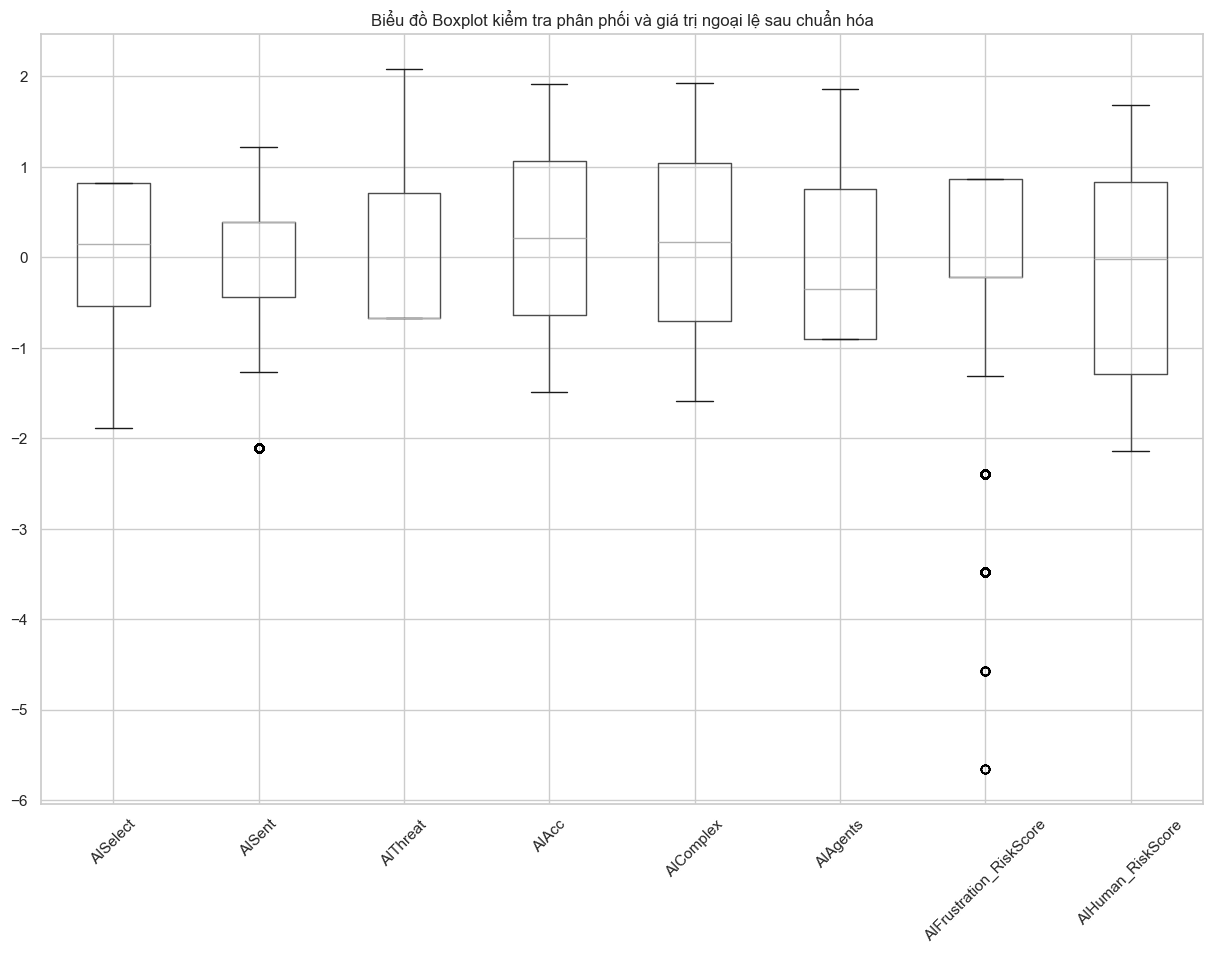

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Vẽ biểu đồ phân phối cho các biến đã chuẩn hóa
plt.figure(figsize=(15, 10))
df_scaled.boxplot()
plt.xticks(rotation=45)
plt.title("Biểu đồ Boxplot kiểm tra phân phối và giá trị ngoại lệ sau chuẩn hóa")
plt.show()

Các hộp (box) nằm tương đối ngang hàng nhau, nghĩa là việc Scaling đã thành công. Các dấu chấm nằm ngoài râu nến là các lập trình viên có hành vi "cực đoan" (ví dụ: cực kỳ ghét AI hoặc cực kỳ phụ thuộc AI), đây là những đối tượng thú vị để K-Means phân cụm.

### 2. Phân tích Tương quan (Correlation Analysis) 

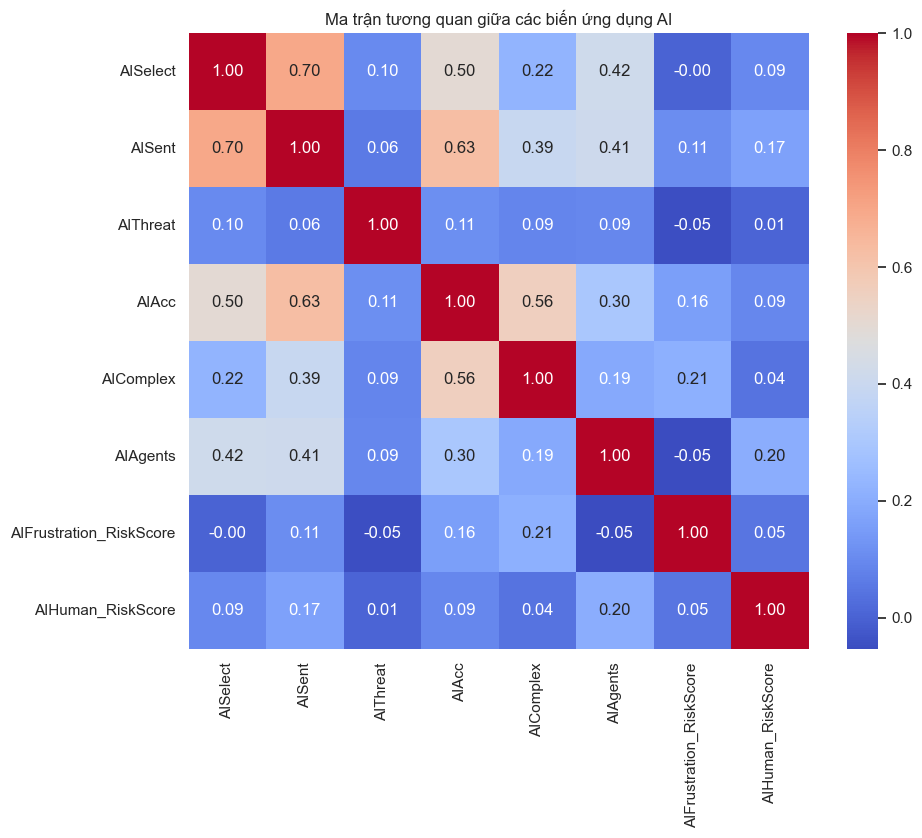

In [28]:
plt.figure(figsize=(10, 8))
correlation_matrix = df_scaled.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Ma trận tương quan giữa các biến ứng dụng AI")
plt.show()

AISelect tương quan thuận cao với AIAcc: Người dùng AI càng nhiều thì càng tin tưởng vào độ chính xác của nó.
AIThreat tương quan nghịch với AIHuman_RiskScore: Người cảm thấy bị đe dọa thường là những người vẫn còn tin vào giá trị con người.

### 3. Xác định số cụm K tối ưu (Elbow Method)

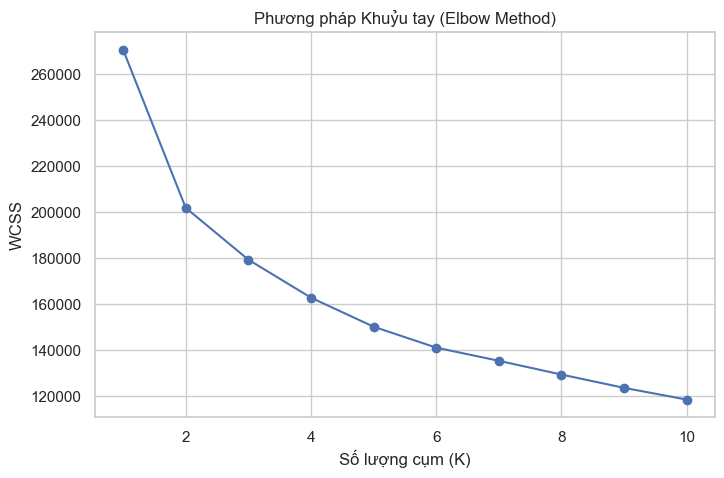

In [29]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Phương pháp Khuỷu tay (Elbow Method)')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

Nếu chọn K=4: Bạn sẽ phân hóa được các nhóm lập trình viên một cách tinh tế hơn, ví dụ:

Nhóm Chuyên gia thích nghi: Dùng AI cực thạo, điểm rủi ro thấp vì họ làm chủ công cụ.

Nhóm Phụ thuộc (Nguy cơ cao): Dùng AI rất nhiều nhưng thiếu tư duy phản biện, điểm rủi ro cao nhất.

Nhóm Truyền thống: Ít dùng AI, làm việc theo cách cũ, điểm rủi ro trung bình.

Nhóm Thận trọng/Hoài nghi: Dùng AI hạn chế vì thấy nhiều lỗi (Frustration cao), điểm rủi ro thấp.

## VI. XÂY DỰNG & ĐÁNH GIÁ MÔ HÌNH (MODELING)


### 1. Xây Dựng mô hình 

In [30]:
from sklearn.cluster import KMeans

# 1. Khởi tạo mô hình với K=4 (dựa trên biểu đồ Elbow)
kmeans_final = KMeans(n_clusters=4, init='k-means++', random_state=42)

# 2. Huấn luyện mô hình trên dữ liệu đã chuẩn hóa
clusters = kmeans_final.fit_predict(df_scaled)

# 3. Gán kết quả phân cụm vào DataFrame gốc để phân tích insight
# Chúng ta gán vào df_imputed để sau này xem được cả các cột chữ (DevType, YearsCode...)
df_results = df_imputed.copy()
df_results['Cluster'] = clusters

print("--- PHÂN CỤM HOÀN TẤT ---")
print(df_results['Cluster'].value_counts())
display(df_results.head())

--- PHÂN CỤM HOÀN TẤT ---
Cluster
0    9525
1    8545
3    8253
2    7513
Name: count, dtype: int64


,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,AILearnHow,...,AIAcc,AIComplex,AIToolDon't plan to use AI for this task,AIFrustration,AIExplain,AIAgents,AIAgentChange,AIHuman,JobSat,Cluster
0,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,...,Neither trust nor distrust,Bad at handling complex tasks,Project planning;Deployment and monitoring;Lea...,"AI solutions that are almost right, but not quite",No,"Yes, I use AI agents at work monthly or infreq...",Not at all or minimally,When I don’t trust AI’s answers,10.0,0
1,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,None of the above,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps,...,Neither trust nor distrust,Bad at handling complex tasks,Learning about a codebase;Project planning;Com...,"AI solutions that are almost right, but not qu...",No,"No, and I don't plan to",Not at all or minimally,When I don’t trust AI’s answers;When I want to...,9.0,0
2,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Technical ...,...,Somewhat trust,Neither good or bad at handling complex tasks,Learning about a codebase;Project planning;Wri...,"AI solutions that are almost right, but not qu...",No,"Yes, I use AI agents at work weekly","Yes, somewhat",When I don’t trust AI’s answers;When I want to...,8.0,1
3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",AI CodeGen tools or AI-enabled apps;Videos (no...,...,Somewhat trust,Bad at handling complex tasks,Project planning;Documenting code;Testing code...,"AI solutions that are almost right, but not qu...",NO,"Yes, I use AI agents at work monthly or infreq...",Not at all or minimally,When I don’t trust AI’s answers;When I want to...,6.0,1
4,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",Technical documentation (is generated for/by t...,...,Neither trust nor distrust,"Good, but not great at handling complex tasks",Project planning;Documenting code;Testing code...,"AI solutions that are almost right, but not quite",partly,"No, and I don't plan to","Yes, to a great extent",When I don’t trust AI’s answers,7.0,3


### 2. Đánh giá mô hình

In [31]:
from sklearn.metrics import silhouette_score

sil_score = silhouette_score(df_scaled, clusters)
print(f"Chỉ số Silhouette của mô hình (K=4): {sil_score:.3f}")

Chỉ số Silhouette của mô hình (K=4): 0.163


Đoạn code phân tích đặc điểm các cụm

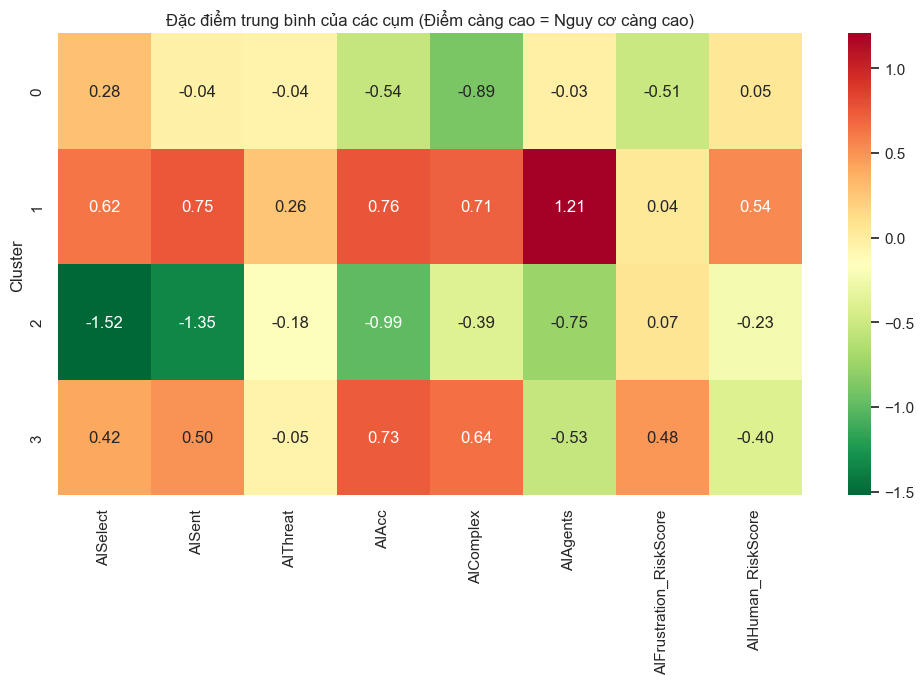

--- SỐ LƯỢNG LẬP TRÌNH VIÊN TRONG MỖI CỤM ---
Cluster
0    9525
1    8545
2    7513
3    8253
Name: count, dtype: int64


In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tính toán giá trị trung bình của các biến rủi ro cho từng cụm
cluster_features = df_scaled.copy()
cluster_features['Cluster'] = clusters
cluster_summary = cluster_features.groupby('Cluster').mean()

# 2. Trực quan hóa bằng Heatmap để so sánh các cụm
plt.figure(figsize=(12, 6))
sns.heatmap(cluster_summary, annot=True, cmap='RdYlGn_r', fmt=".2f")
plt.title('Đặc điểm trung bình của các cụm (Điểm càng cao = Nguy cơ càng cao)')
plt.show()

# 3. Xem xét quy mô của từng cụm
print("--- SỐ LƯỢNG LẬP TRÌNH VIÊN TRONG MỖI CỤM ---")
print(df_results['Cluster'].value_counts().sort_index())

Đối chiếu với bối cảnh 

In [33]:
# Gộp nhãn cụm vào tập context
df_context_results = df_imputed[['YearsCode', 'DevType', 'Age']].copy()
df_context_results['Cluster'] = clusters

# Kiểm tra số năm kinh nghiệm trung bình của từng cụm
# Lưu ý: Cần chuyển YearsCode về dạng số nếu nó đang là chuỗi
df_context_results['YearsCode'] = pd.to_numeric(df_context_results['YearsCode'], errors='coerce')

print("\n--- PHÂN TÍCH BỐI CẢNH KINH NGHIỆM THEO CỤM ---")
display(df_context_results.groupby('Cluster')['YearsCode'].mean())


--- PHÂN TÍCH BỐI CẢNH KINH NGHIỆM THEO CỤM ---


Cluster
0    16.856588
1    16.208075
2    19.778917
3    16.473161
Name: YearsCode, dtype: float64